# Machine Learning: Yield Prediction (Regression)
**Project:** KCropAI  
**Dataset:** `crop_yield_kerala.csv`

### Objective
While our classification model recommends *which* crop to plant, this regression model predicts *how much* yield a farmer can expect. 

We will train a **Random Forest Regressor** to predict the `Yield` based on:
1. Crop Type
2. Land Area
3. Annual Rainfall
4. Fertilizer Usage
5. Pesticide Usage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style="whitegrid")
print("Import Success")

Import Success


In [2]:
# 1. Load the localized yield dataset
print("Loading Localized Yield Dataset...")
df = pd.read_csv('../data/crop_yield_kerala.csv')

# 2. Clean the data (Drop missing values in crucial columns)
df = df.dropna(subset=['Yield', 'Crop', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide'])

# 3. Select Features (X) and Target (y)
features = ['Crop', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
X = df[features].copy()
y = df['Yield']

# 4. Encode the Categorical 'Crop' column
# Regression models need numbers, not text!
label_encoder = LabelEncoder()
X['Crop_Encoded'] = label_encoder.fit_transform(X['Crop'])

# Drop the original text column
X = X.drop('Crop', axis=1)

print(f"Dataset ready: {X.shape[0]} samples.")
display(X.head())

Loading Localized Yield Dataset...
Dataset ready: 19689 samples.


,Area,Annual_Rainfall,Fertilizer,Pesticide,Crop_Encoded
0,73814.0,2051.4,7024878.38,22882.34,0
1,6637.0,2051.4,631643.29,2057.47,1
2,796.0,2051.4,75755.32,246.76,8
3,19656.0,2051.4,1870661.52,6093.36,9
4,1739.0,2051.4,165500.63,539.09,11


### Model Training & Evaluation
We will use a Random Forest Regressor because agricultural data often contains non-linear relationships (e.g., adding twice as much fertilizer doesn't always equal exactly twice the yield).

In [3]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Regressor
print("Training the Random Forest Regressor")
reg_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
reg_model.fit(X_train, y_train)
print("Model Training Complete!")

# Make predictions
y_pred = reg_model.predict(X_test)

Training the Random Forest Regressor
Model Training Complete!


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 12.05
Root Mean Squared Error (RMSE): 152.69
R-Squared Score (R2): 0.97


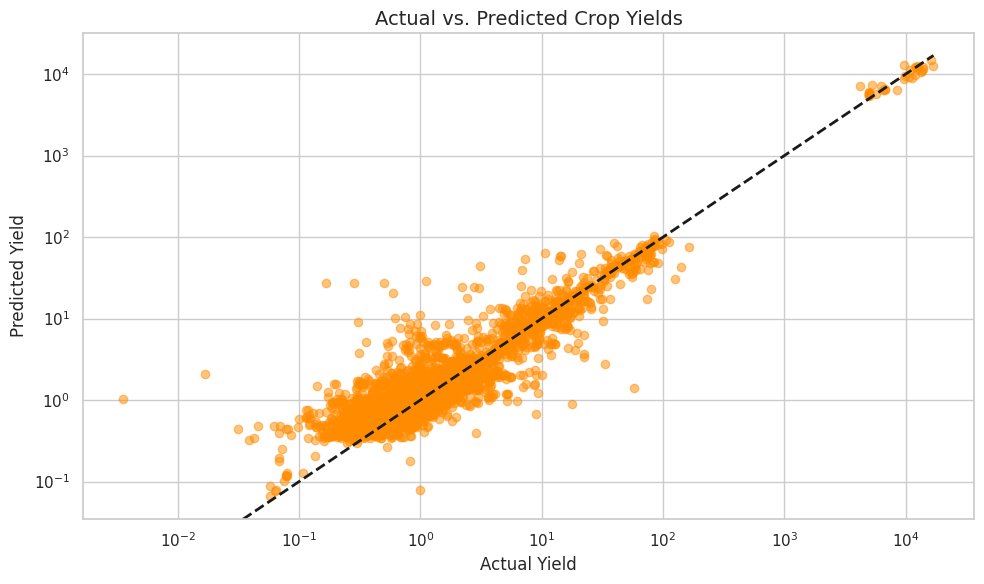

In [4]:
# Calculate Error Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared Score (R2): {r2:.2f}")

# Visualize Actual vs. Predicted Yields
plt.figure(figsize=(10, 6))
# Using a scatter plot to show how close predictions are to the actual values
plt.scatter(y_test, y_pred, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Actual vs. Predicted Crop Yields", fontsize=14)
plt.xlabel("Actual Yield", fontsize=12)
plt.ylabel("Predicted Yield", fontsize=12)

# Use a logarithmic scale if extreme outliers (like Coconuts) compress the graph
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

### Exporting the Model
Just like the classification model, we must export this regression model and its specific label encoder so our Streamlit UI can use it to make live predictions.

In [5]:
import os

os.makedirs('../src', exist_ok=True)

# Save the Regressor model
reg_model_path = '../src/rf_yield_regressor.pkl'
joblib.dump(reg_model, reg_model_path, compress=3)

# Save the Encoder
reg_encoder_path = '../src/crop_label_encoder.pkl'
joblib.dump(label_encoder, reg_encoder_path)

print(f"Regression Model saved to: {reg_model_path}")
print(f"Crop Label Encoder saved to: {reg_encoder_path}")
print("All Machine Learning requirements complete")

Regression Model saved to: ../src/rf_yield_regressor.pkl
Crop Label Encoder saved to: ../src/crop_label_encoder.pkl
All Machine Learning requirements complete
